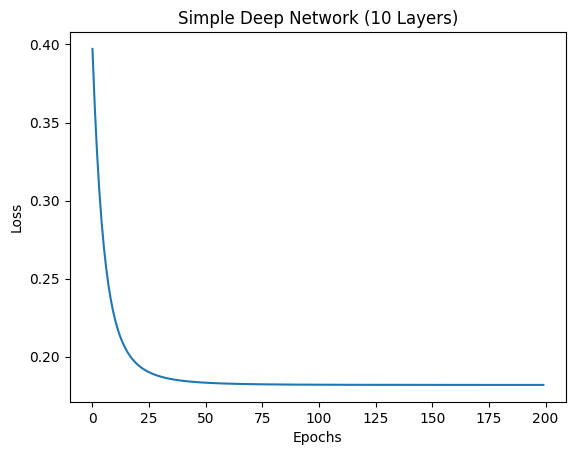

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# Random Initialization (not Xavier)
def init_weights(n_in, n_out):
    return np.random.randn(n_in, n_out) * 0.01

# Network structure
layers = [2,10,10,10,10,10,10,10,10,10,1]
weights = []
biases = []

for i in range(len(layers)-1):
    weights.append(init_weights(layers[i], layers[i+1]))
    biases.append(np.zeros((1, layers[i+1])))

# Dummy data
X = np.random.rand(100,2)
y = (X[:,0] + X[:,1]).reshape(-1,1)

epochs = 200
lr = 0.1
losses = []

for epoch in range(epochs):
    activations = [X]

    # Forward
    for i in range(len(weights)):
        z = np.dot(activations[-1], weights[i]) + biases[i]
        a = sigmoid(z)
        activations.append(a)

    loss = np.mean((activations[-1] - y)**2)
    losses.append(loss)

    # Backward
    dz = activations[-1] - y
    for i in reversed(range(len(weights))):
        dw = np.dot(activations[i].T, dz) / len(X)
        db = np.sum(dz, axis=0, keepdims=True) / len(X)
        dz = np.dot(dz, weights[i].T) * sigmoid_derivative(activations[i])
        weights[i] -= lr * dw
        biases[i] -= lr * db

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Simple Deep Network (10 Layers)")
plt.show()


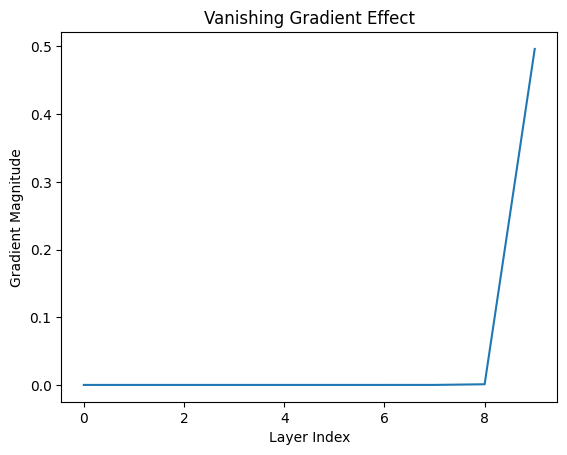

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

layers = [2,10,10,10,10,10,10,10,10,10,1]
weights = [np.random.randn(layers[i], layers[i+1])*0.01 for i in range(len(layers)-1)]

X = np.random.rand(1,2)
gradients = []

activation = X
activations = [X]

# Forward
for w in weights:
    activation = sigmoid(np.dot(activation, w))
    activations.append(activation)

# Backward (track gradients)
dz = activations[-1]
for i in reversed(range(len(weights))):
    grad = np.mean(np.abs(dz))
    gradients.append(grad)
    dz = np.dot(dz, weights[i].T) * sigmoid_derivative(activations[i])

gradients.reverse()

plt.plot(gradients)
plt.xlabel("Layer Index")
plt.ylabel("Gradient Magnitude")
plt.title("Vanishing Gradient Effect")
plt.show()


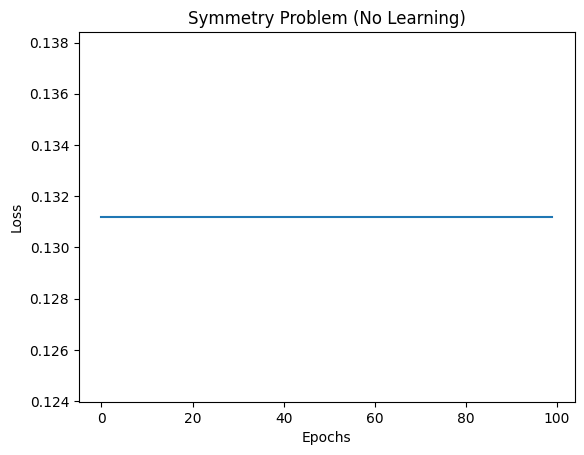

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1/(1+np.exp(-z))

X = np.random.rand(100,2)
y = (X[:,0] + X[:,1]).reshape(-1,1)

# Same weights (symmetry problem)
W1 = np.ones((2,5))
W2 = np.ones((5,1))
b1 = np.zeros((1,5))
b2 = np.zeros((1,1))

lr = 0.1
losses = []

for epoch in range(100):
    h = sigmoid(np.dot(X, W1) + b1)
    y_pred = sigmoid(np.dot(h, W2) + b2)

    loss = np.mean((y_pred - y)**2)
    losses.append(loss)

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Symmetry Problem (No Learning)")
plt.show()


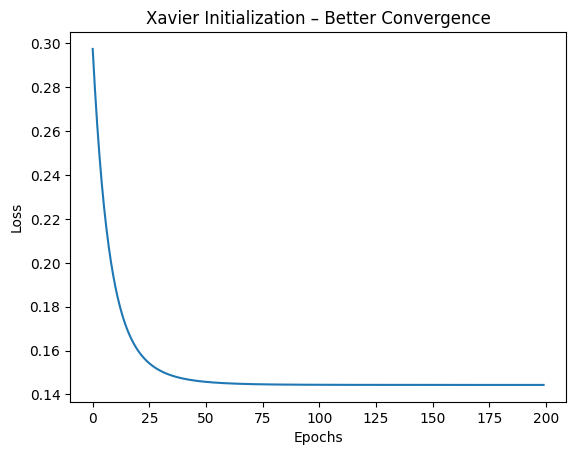

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoid_derivative(a):
    return a*(1-a)

def xavier(n_in, n_out):
    return np.random.randn(n_in, n_out) * np.sqrt(2/(n_in+n_out))

layers = [2,10,10,10,10,10,10,10,10,10,1]
weights = [xavier(layers[i], layers[i+1]) for i in range(len(layers)-1)]
biases = [np.zeros((1, layers[i+1])) for i in range(len(layers)-1)]

X = np.random.rand(100,2)
y = (X[:,0] + X[:,1]).reshape(-1,1)

epochs = 200
lr = 0.1
losses = []

for epoch in range(epochs):
    activations = [X]
    for i in range(len(weights)):
        z = np.dot(activations[-1], weights[i]) + biases[i]
        activations.append(sigmoid(z))

    loss = np.mean((activations[-1] - y)**2)
    losses.append(loss)

    dz = activations[-1] - y
    for i in reversed(range(len(weights))):
        dw = np.dot(activations[i].T, dz) / len(X)
        dz = np.dot(dz, weights[i].T) * sigmoid_derivative(activations[i])
        weights[i] -= lr * dw

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Xavier Initialization – Better Convergence")
plt.show()
